# Oil Pipeline Accidents, 2010-2016
### Projekt Pad
### Martin Molnár

# Úvod

V našej analýze sme použili dataset Pipeline Accidents, ktorý nájdeme na adrese: https://www.kaggle.com/datasets/usdot/pipeline-accidents.

Dataset obsahuje záznamy o všetkých únikoch alebo haváriách ropných potrubí, ktoré boli nahlásené správe Pipeline and Hazardous Materials Safety Administration (PHMSA) od roku 2010 do roku 2016. Tieto záznamy zahŕňajú dátum a čas incidentu, operátora a potrubie, príčinu incidentu, typ uniknutej nebezpečnej látky a množstvo, počet zranení a úmrtí, ako aj s tým spojené náklady.

Dataset bol zozbieraný a publikovaný Ministerstvom dopravy USA (DOT) prostredníctvom Pipeline and Hazardous Materials Safety Administration a poskytuje detailné údaje na analýzu havárií ropných potrubí.

Dataset zahŕňa kľúčové údaje ktoré použijeme a tie sú:
- Accident Year: Rok, kedy sa nehoda stala.
- Accident State: Štát v USA, kde sa nehoda odohrala.
- Cause Category: Kategória hlavnej príčiny nehody.
- Pipeline Location: Miesto potrubia, či je ONSHORE (na súši) alebo OFFSHORE (na mori).
- Pipeline Type: Typ potrubia.
- All Costs: Celkové finančné náklady spojené s nehodou (zahŕňajú škody na majetku, straty komodity, environmentálne náklady, atď.).
- Unintentional Release (Barrels): Počet barelov kvapaliny neúmyselne vypustených do okolia.
- Liquid Ignition: Indikátor, či došlo k vzplanutiu uniknutej kvapaliny.
- Liquid Explosion: Indikátor, či došlo k výbuchu uniknutej kvapaliny.
- Net Loss (Barrels): Čistá strata kvapaliny v bareloch.

V úvodnom kroku pre prácu s dátami si importujeme vhodné knižnice a zvolený
dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import seaborn as sns
df = pd.read_csv('oil_pipeline.csv', sep=',')

Následne si vykreslíme čast datasetu pre základný prehľad.

In [6]:
df.head()

,Report Number,Supplemental Number,Accident Year,Accident Date/Time,Operator ID,Operator Name,Pipeline/Facility Name,Pipeline Location,Pipeline Type,Liquid Type,...,Other Fatalities,Public Fatalities,All Fatalities,Property Damage Costs,Lost Commodity Costs,Public/Private Property Damage Costs,Emergency Response Costs,Environmental Remediation Costs,Other Costs,All Costs
0,20100016,17305,2010,1/1/2010 7:15 AM,32109,ONEOK NGL PIPELINE LP,KINDER MORGAN JCT,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,NaN,NaN,NaN,110.0,1517.0,0.0,0.0,0.0,0.0,1627
1,20100254,17331,2010,1/4/2010 8:30 AM,15786,PORTLAND PIPELINE CORP,24-INCH MAIN LINE,ONSHORE,ABOVEGROUND,CRUDE OIL,...,NaN,NaN,NaN,4000.0,8.0,0.0,0.0,0.0,0.0,4008
2,20100038,17747,2010,1/5/2010 10:30 AM,20160,"PETROLOGISTICS OLEFINS, LLC",NaN,ONSHORE,ABOVEGROUND,"HVL OR OTHER FLAMMABLE OR TOXIC FLUID, GAS",...,NaN,NaN,NaN,0.0,200.0,0.0,0.0,0.0,0.0,200
3,20100260,18574,2010,1/6/2010 7:30 PM,11169,"ENBRIDGE ENERGY, LIMITED PARTNERSHIP",SUPERIOR TERMINAL,ONSHORE,UNDERGROUND,CRUDE OIL,...,NaN,NaN,NaN,200.0,40.0,0.0,11300.0,0.0,0.0,11540
4,20100030,16276,2010,1/7/2010 1:00 PM,300,"PLAINS PIPELINE, L.P.",RED RIVER EAST,ONSHORE,UNDERGROUND,CRUDE OIL,...,NaN,NaN,NaN,20000.0,150.0,0.0,7500.0,2000.0,0.0,29650


## Exploračná analýza - prehľad

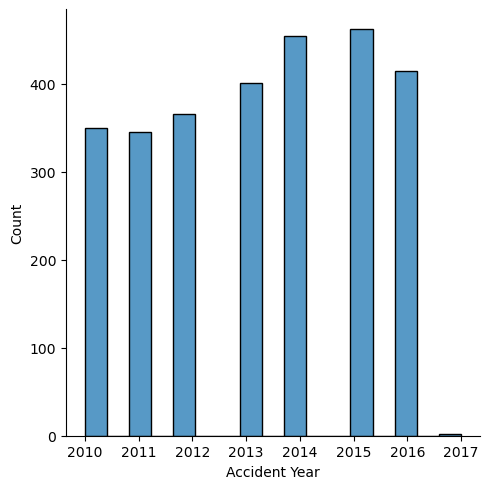

In [8]:
plot = sns.displot(df["Accident Year"])

Záver: Vidíme, že v každom roku sa stalo viac ako 350 nehôd. Rok 2015 vyniká ako rok s najvyšším počtom nehôd v porovnaní s ostatnými rokmi v analyzovanom období.

Čo ďalej: Poďme si analyzovať, ktoré štáty majú najviac nehôd.

<Axes: ylabel='count'>

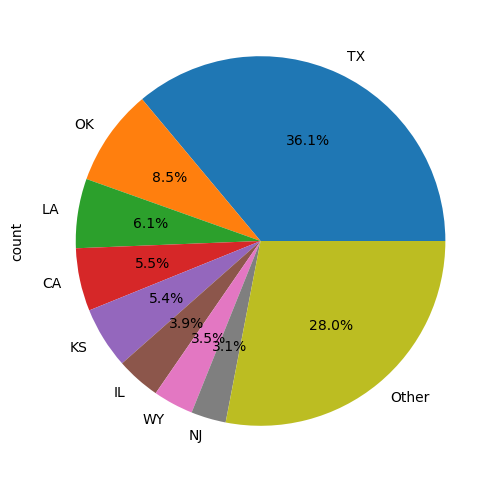

In [10]:
operator_counts = df['Accident State'].value_counts()
threshold = 0.03 * operator_counts.sum()

operator_counts_grouped = operator_counts.copy()
operator_counts_grouped[operator_counts_grouped < threshold] = 0
operator_counts_grouped['Other'] = operator_counts[operator_counts < threshold].sum()

operator_counts_grouped = operator_counts_grouped[operator_counts_grouped > 0]
operator_counts_grouped.plot(kind='pie',autopct='%1.1f%%',figsize=(6, 6)
)

Záver: Zistili sme, že nehody sú výrazne koncentrované v niekoľkých kľúčových štátoch, pričom Texas (36.2 %) dominuje ako štát s najvyšším počtom incidentov. Ďalšími významnými štátmi sú Oklahoma (8.5 %), Louisiana (5.9 %), a Kalifornia (5.5 %)

Čo ďalej: Zobrazme si počet nehôd podľa typu.

Cause Category
MATERIAL/WELD/EQUIP FAILURE    1435
CORROSION                       592
INCORRECT OPERATION             378
NATURAL FORCE DAMAGE            118
ALL OTHER CAUSES                118
EXCAVATION DAMAGE                97
OTHER OUTSIDE FORCE DAMAGE       57
Name: count, dtype: int64


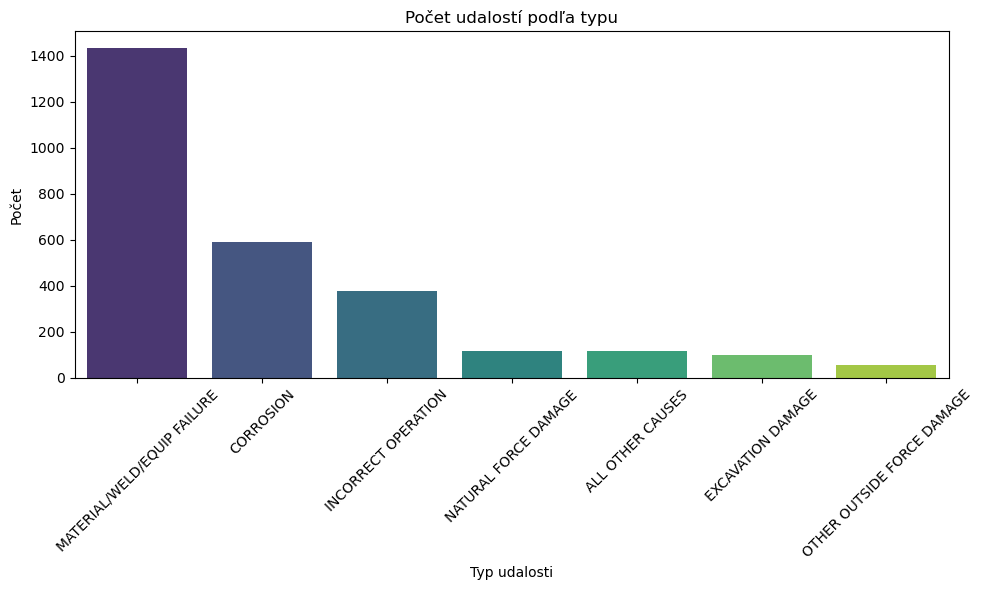

In [12]:
event_counts = df['Cause Category'].value_counts()
print(event_counts)

plt.figure(figsize=(10,6))
sns.barplot(x=event_counts.index, y=event_counts.values, hue=event_counts.index, palette='viridis',dodge=False)
plt.title('Počet udalostí podľa typu')
plt.xlabel('Typ udalosti')
plt.ylabel('Počet')
plt.xticks(rotation=45)
plt.legend([],[], frameon=False) 
plt.tight_layout()
plt.show()

Záver: Najčastejšou príčinou nehôd v ropovodoch a plynovodoch je Material/Weld/Equip Failure (materiálové zlyhanie, zlyhanie zvárania alebo zariadení), ktorá predstavuje výrazne najväčší podiel udalostí s počtom viac než 1400 prípadov.  

Pipeline Location
ONSHORE     2777
OFFSHORE      18
Name: count, dtype: int64


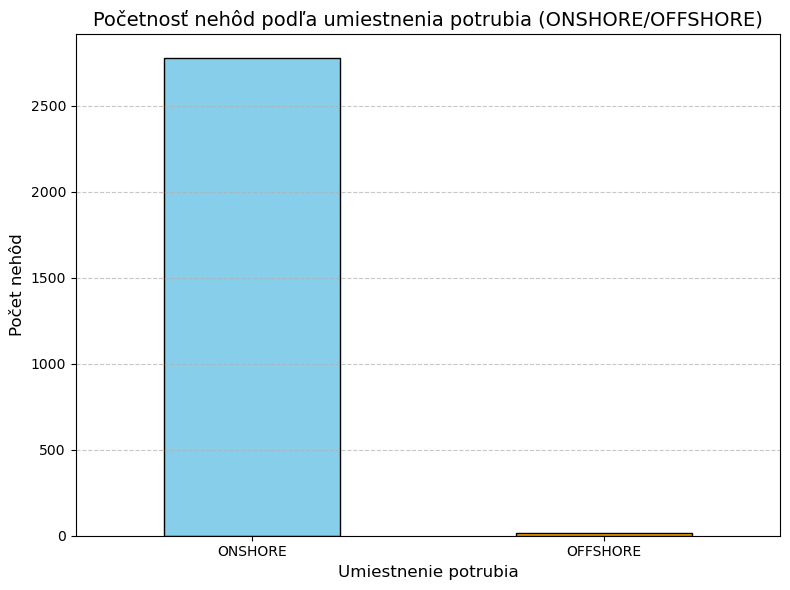

In [14]:
location_counts = df['Pipeline Location'].value_counts()
print(location_counts)

plt.figure(figsize=(8, 6))
location_counts.plot(kind='bar', color=['skyblue', 'orange'], edgecolor='black')

plt.title('Početnosť nehôd podľa umiestnenia potrubia (ONSHORE/OFFSHORE)', fontsize=14)
plt.xlabel('Umiestnenie potrubia', fontsize=12)
plt.ylabel('Počet nehôd', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

Záver: Zistili sme, že takmer všetky nehody sa stali na pevnine.

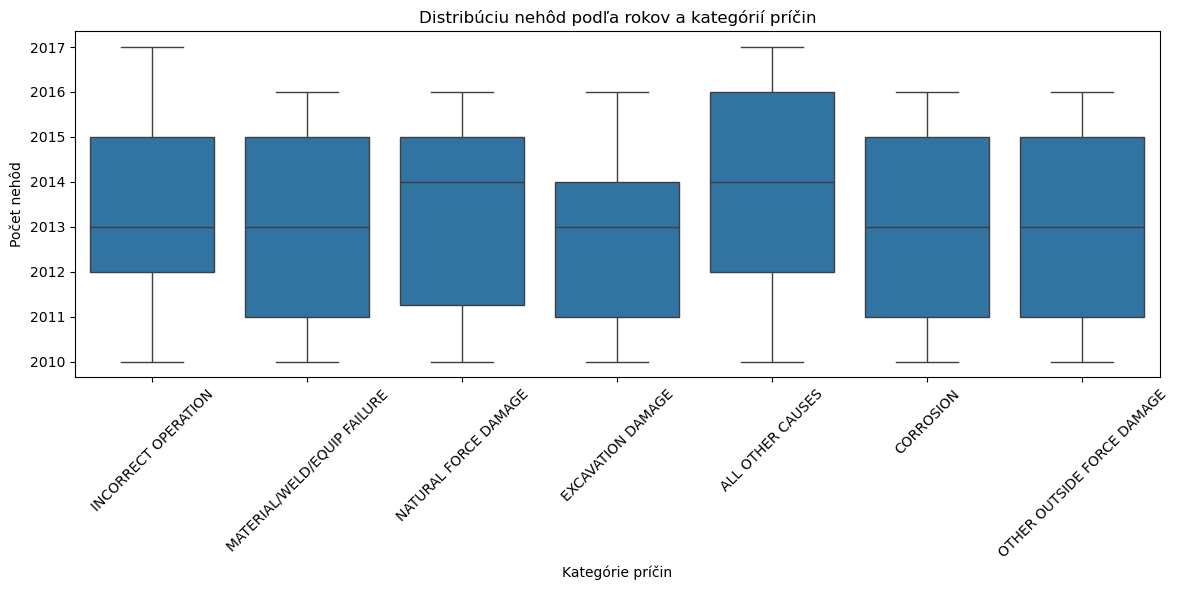

In [16]:
df['Cause Category'].value_counts()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Cause Category', y='Accident Year')  
plt.title('Distribúciu nehôd podľa rokov a kategórií príčin')
plt.xticks(rotation=45)
plt.xlabel('Kategórie príčin')
plt.ylabel('Počet nehôd')
plt.tight_layout()
plt.show()

Záver: Kategória ALL OTHER CAUSES vykazuje väčší rozptyl v počte nehôd počas rokov, čo môže naznačovať, že nehody spôsobené touto kategóriou sú menej predvídateľné. NATURAL FORCE DAMAGE, vykazuje niekoľko extrémnych hodnôt, čo môže byť dôsledkom prírodných katastrôf v určitých rokoch.

Čo ďalej: Poďme sa pozrieť na rozdelenie nákladov spojených s nehodami podľa typu potrubia.


In [18]:
df['All Costs Interval'] = pd.cut( df['All Costs'],bins=[0, 5000, 20000, 50000, 100000, df['All Costs'].max()], labels=['0-5k', '5k-20k', '20k-50k', '50k-100k', '100k+'] )
pivot_table = pd.pivot_table(df,values='All Costs', index='Pipeline Type',columns='All Costs Interval',aggfunc=np.count_nonzero,fill_value=0,
observed=False,margins=True)
pivot_table

All Costs Interval,0-5k,5k-20k,20k-50k,50k-100k,100k+,All
Pipeline Type,,,,,,
ABOVEGROUND,524.0,428.0,236.0,95.0,176.0,1459
TANK,52.0,63.0,58.0,31.0,90.0,294
TRANSITION AREA,5.0,5.0,0.0,1.0,5.0,16
UNDERGROUND,69.0,139.0,197.0,108.0,462.0,975
All,650.0,635.0,491.0,235.0,733.0,2744


Záver: Potrubia typu ABOVEGROUND vykazujú najväčší počet nehôd (1459), pričom väčšina z nich patrí do nižších kategórií nákladov. Naopak, potrubia typu UNDERGROUND sú spojené s vyšším počtom vysokonákladových prípadov (100k+), čo naznačuje väčšiu finančnú náročnosť opráv pri nehodách podzemných potrubí.

In [20]:
df['Unintentional Release Interval'] = pd.cut(
    df['Unintentional Release (Barrels)'].fillna(0),
    bins=[0, 10, 50, 200, 500, 1000, df['Unintentional Release (Barrels)'].max()],
    labels=['0-10', '10-50', '50-200', '200-500', '500-1000', '1000+']
)

pivot_table_release = pd.pivot_table( df,values='Unintentional Release (Barrels)',index='Pipeline Type',columns='Unintentional Release Interval',  
    aggfunc=np.count_nonzero,fill_value=0,observed=False,margins=True)

pivot_table_release

Unintentional Release Interval,0-10,10-50,50-200,200-500,500-1000,1000+,All
Pipeline Type,,,,,,,
ABOVEGROUND,1146.0,163.0,91.0,33.0,15.0,17.0,1465
TANK,199.0,39.0,26.0,15.0,6.0,9.0,294
TRANSITION AREA,11.0,3.0,1.0,0.0,1.0,0.0,16
UNDERGROUND,560.0,145.0,100.0,62.0,40.0,67.0,974
All,1916.0,350.0,218.0,110.0,62.0,93.0,2749


Záver: Nadzemné potrubia vykazujú najvyšší počet incidentov s nízkym objemom únikov (0-10 barelov), čo naznačuje ich vyššiu expozíciu menším nehodám. Naopak, podzemné potrubia sú častejšie spojené s vysokými únikmi (1000+ barelov).

# Analýza 1
## Inferenčná analýza - testy o stredných hodnotách

Chceme overiť, či je štatisticky významný rozdiel medzi priemernými nákladmi na incidenty pre nadzemné potrubia (ABOVEGROUND) a podzemné potrubia (UNDERGROUND). Naformulujeme preto nulovú hypotézu.

H0: Nie je štatisticky významný rozdiel medzi priemernými nákladmi na incidenty pre nadzemné potrubia (ABOVEGROUND) a podzemné potrubia (UNDERGROUND).

Na overenie použijeme softvér Statistica (Molnar_projekt/WorkBook1).

Najprv si vyberieme t-test pre nezávislé výbery, ktorý je vhodný na porovnávanie priemerov medzi dvoma nezávislými skupinami. Tento test nám umožní zistiť, či existuje štatisticky významný rozdiel medzi priemernými nákladmi na incidenty pre nadzemné potrubia (ABOVEGROUND) a podzemné potrubia (UNDERGROUND).

In [24]:
ttest1 = pd.read_csv("ttest1.csv", sep=";")
ttest1

,Mean ABOVEGROUND,Mean UNDERGROUND,t-value,df,p,Valid N ABOVEGROUND,Valid N UNDERGROUND,Std.Dev. ABOVEGROUND,Std.Dev. UNDERGROUND,F-ratio Variances,p Variances,"Levene F (1,df)",df Levene,p Levene
0,"104089,9",2112992,"-2,76826",2458,"0,005678",1475,985,"711613,5",27859963,"1532,755",0,"21,30444",2458,"0,000004"


Vo výsledkoch vidíme, že p-hodnota Leveneovho testu je 0.000004, čo je výrazne menej ako 0.05. To znamená, že rozptyly medzi dvoma skupinami nie sú rovnaké. Ak rozptyly nie sú rovnaké, klasický Studentov t-test nemôže byť použitý, pretože predpokladá rovnosť rozptylov. Preto použijeme Welchov t-test, pretože nepredpokladá rovnosť rozptylov.

In [26]:
ttest2 = pd.read_csv("ttest2.csv", sep=";")
ttest2

,Mean ABOVEGROUND,Mean UNDERGROUND,t-value,df,p,t separ.var.est,df.1,p 2-sided,Valid N ABOVEGROUND,Valid N UNDERGROUND,Std.Dev. ABOVEGROUND,Std.Dev. UNDERGROUND,F-ratio Variances,p Variances
0,"104089,9",2112992,"-2,76826",2458,"0,005678","-2,26257","984,8575","0,023879",1475,985,"711613,5",27859963,"1532,755",0


Na základe výsledkov test H0 zamietame.

Záver: Oba testy ukazujú, že existuje štatisticky významný rozdiel v priemerných nákladoch medzi nadzemnými a podzemnými potrubiami.Welchov t-test poskytol p-hodnotu 0.023879, čo je vyššia, ale stále štatisticky významná (p < 0.05).

# Analýza 2
## Inferenčná analýza - Korelačná analýza

V prvej analýze sa zameriame na to, či hodnota zápalu tekutiny zvyšuje výskyt výbuchu tekutiny.

Budeme teda zisťovať úroveň korelačného koeficientu medzi dvojicami:
- Liquid Ignition
- Liquid Explosion

Naformulujeme teda nulovú hypotézu:
- H0 (A): Nie je štatisticky významná závislosť medzi premennými Liquid Ignition a Liquid Explosion.

Keďže máme veľké množstvo záznamov, môžeme použiť parametrické metódy korelačnej analýzy.

In [30]:
df['Liquid Ignition Numeric'] = df['Liquid Ignition'].map({'YES': 1, 'NO': 0})
df['Liquid Explosion Numeric'] = df['Liquid Explosion'].map({'YES': 1, 'NO': 0})
correlation = df[['Liquid Ignition Numeric', 'Liquid Explosion Numeric']].corr()
print(correlation)


                          Liquid Ignition Numeric  Liquid Explosion Numeric
Liquid Ignition Numeric                  1.000000                  0.391601
Liquid Explosion Numeric                 0.391601                  1.000000


Zistili sme, že korelačný koeficient je 0,39.

Overme aj p-hodnotu.

In [32]:
stats.pearsonr(df["Liquid Ignition Numeric"], df["Liquid Explosion Numeric"])

PearsonRResult(statistic=0.3916005661484819, pvalue=4.197242415951113e-103)

Záver: Na základe výsledkov korelačnej analýzy sme zistili, že korelačný koeficient medzi zápalom tekutiny a výbuchom je 0,39, čo naznačuje stredne silný kladný vzťah medzi týmito premennými. To znamená, že výskyt zápalu tekutiny zvyšuje pravdepodobnosť výbuchu.
Hodnota p-value je 4,197 × 10⁻¹⁰³, čo je extrémne nízka hodnota a jednoznačne menšia ako hladina významnosti (napr. 0,05). To nám umožňuje zamietnuť nulovú hypotézu (H0) a potvrdiť, že medzi zápalom tekutiny a výbuchom existuje štatisticky významný vzťah.

V druhej analýze sa zameriame na to, či výška celkových nákladov súvisí so stratou objemu tekutiny (Net Loss).

Budeme teda zisťovať úroveň korelačného koeficientu medzi dvojicami premenných:
- All Costs
- Net Loss (Barrels)

H0 (A):  Nie je štatisticky významná závislosť medzi premennými All Costs a Net Loss (Barrels).
Keďže máme veľké množstvo záznamov, môžeme použiť parametrické metódy korelačnej analýzy, konkrétne Pearsonov korelačný koeficient, ktorý meria silu lineárneho vzťahu medzi premennými.

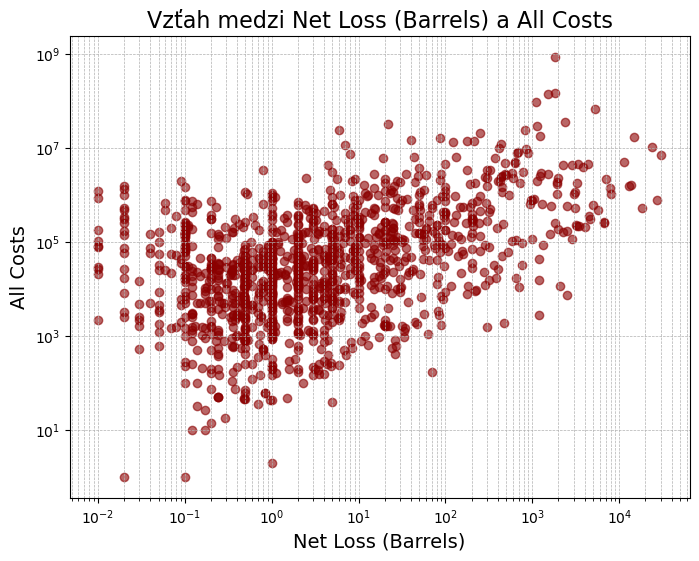

In [35]:
x = df['Net Loss (Barrels)']
y = df['All Costs']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='darkred', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Net Loss (Barrels)', fontsize=14)
plt.ylabel('All Costs', fontsize=14)
plt.title('Vzťah medzi Net Loss (Barrels) a All Costs', fontsize=16)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [36]:
correlation=df[["All Costs","Net Loss (Barrels)"]].corr()
print(correlation)


                    All Costs  Net Loss (Barrels)
All Costs            1.000000            0.061923
Net Loss (Barrels)   0.061923            1.000000


Zistili sme, že korelačný koeficient je 0,061.

Overme aj p-hodnotu.

In [38]:
stats.pearsonr(df["All Costs"], 
               df["Net Loss (Barrels)"])

PearsonRResult(statistic=0.06192266411110721, pvalue=0.0010551562239196884)

Záver: Korelačný koeficient naznačuje veľmi slabý kladný vzťah medzi celkovými nákladmi a stratou objemu. To znamená, že zvýšenie straty objemu má len minimálny vplyv na zvýšenie celkových nákladov. Hodnota p je menšia ako 0,05, čo znamená, že zamietame nulovú hypotézu (H0) a potvrdzujeme, že existuje štatisticky významná závislosť medzi týmito premennými.

# Záver

V exploračnej analýze sme zistili že, že nehody v ropovodoch a plynovodoch sú výrazne koncentrované v niekoľkých geografických oblastiach a majú opakujúce sa príčiny. Zistili sme, že v každom analyzovanom roku došlo k viac ako 350 nehodám, pričom rok 2015 vyniká najvyšším počtom incidentov. Texas je štátom s najvyšším počtom nehôd (36,2 %), nasledovaný Oklahomou, Louisianou a Kaliforniou. Najčastejšou príčinou nehôd je Material/Weld/Equip Failure, ktorá predstavuje viac než 1400 prípadov, zatiaľ čo nehody kategórie ALL OTHER CAUSES vykazujú väčší rozptyl, čo naznačuje ich menšiu predvídateľnosť. Takmer všetky nehody sa stali na pevnine. Pri skúmaní potrubí sme zistili, že nadzemné potrubia (ABOVEGROUND) majú najväčší počet nehôd, pričom väčšina z nich patrí do nižších nákladových kategórií. Naopak, podzemné potrubia (UNDERGROUND) sú častejšie spojené s vysokonákladovými prípadmi a veľkými únikmi.

Na základe vykonanej analýzy 1 sme zistili, že existuje štatisticky významný rozdiel medzi priemernými nákladmi na incidenty pre nadzemné potrubia (ABOVEGROUND) a podzemné potrubia (UNDERGROUND). Leveneov test ukázal, že rozptyly medzi týmito dvoma skupinami nie sú rovnaké, a preto sme použili Welchov t-test, ktorý nepredpokladá rovnosť rozptylov. Výsledky Welchovho t-testu s p-hodnotou 0.023879 (p < 0.05) potvrdzujú, že priemerné náklady na incidenty sa medzi nadzemnými a podzemnými potrubiami štatisticky významne líšia. To naznačuje, že podzemné potrubia sú spojené s vyššími nákladmi na riešenie incidentov.

Na základe vykonanej analýzy 2 sme zistili dva zaujímavé vzťahy medzi analyzovanými premennými. Prvá analýza ukázala, že existuje stredne silný kladný vzťah medzi zápalom tekutiny a výbuchom, pričom korelačný koeficient je 0,39. Extrémne nízka p-hodnota potvrdzuje štatistickú významnosť tohto vzťahu, čo znamená, že výskyt zápalu tekutiny výrazne zvyšuje pravdepodobnosť výbuchu. Na druhej strane, druhá analýza odhalila veľmi slabý kladný vzťah medzi celkovými nákladmi a stratou objemu tekutiny, s korelačným koeficientom. Hoci p-hodnota bola štatisticky významná, samotný slabý vzťah naznačuje, že zvýšenie straty objemu má len minimálny vplyv na zvýšenie celkových nákladov, a iné faktory pravdepodobne zohrávajú podstatnejšiu úlohu. 

